<a href="https://colab.research.google.com/github/Mmoralesvasquez/PerpCourseNoreadme-2/blob/main/python_analitica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- TABLA DE DISTRIBUCIÓN DE PROBABILIDAD ---
   Ventas (X)  Probabilidad P(X)  X * P(X)
0          10               0.10       1.0
1          20               0.25       5.0
2          30               0.40      12.0
3          40               0.15       6.0
4          50               0.10       5.0

---------------------------------------------
La Esperanza Matemática (Valor Esperado) es: 29.0 unidades
---------------------------------------------



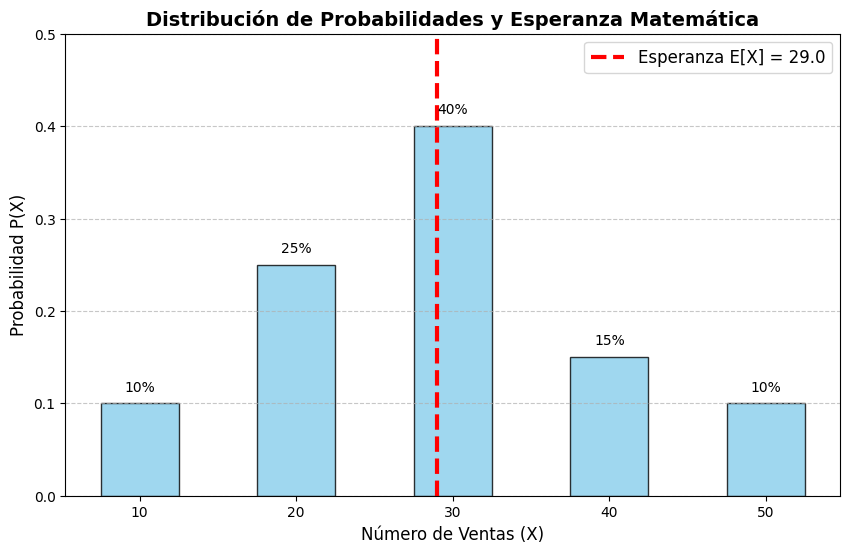

In [1]:
# Ejemplo de Esperanza Matemática: Ventas Diarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINICIÓN DE LOS DATOS
# ==========================================
# Supongamos que X = Número de unidades vendidas de un producto al día
valores_x = np.array([10, 20, 30, 40, 50])

# Probabilidad de que ocurra cada nivel de ventas (basado en datos históricos)
# Nota: La suma de estas probabilidades debe ser siempre 1.0
probabilidades = np.array([0.10, 0.25, 0.40, 0.15, 0.10])

# Creamos un DataFrame para visualizarlo bonito como una tabla
df = pd.DataFrame({
    'Ventas (X)': valores_x,
    'Probabilidad P(X)': probabilidades
})

# ==========================================
# 2. CÁLCULO DE LA ESPERANZA MATEMÁTICA E[X]
# ==========================================
# Multiplicamos cada valor por su probabilidad y luego sumamos todo
df['X * P(X)'] = df['Ventas (X)'] * df['Probabilidad P(X)']
esperanza_matematica = df['X * P(X)'].sum()

print("--- TABLA DE DISTRIBUCIÓN DE PROBABILIDAD ---")
print(df)
print("\n---------------------------------------------")
print(f"La Esperanza Matemática (Valor Esperado) es: {esperanza_matematica} unidades")
print("---------------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos un gráfico de barras para las probabilidades
barras = plt.bar(valores_x, probabilidades, width=5, color='skyblue', edgecolor='black', alpha=0.8)

# Agregamos una línea vertical roja para mostrar dónde cae la Esperanza Matemática
plt.axvline(x=esperanza_matematica, color='red', linestyle='--', linewidth=3, label=f'Esperanza E[X] = {esperanza_matematica}')

# Etiquetas y diseño del gráfico
plt.title('Distribución de Probabilidades y Esperanza Matemática', fontsize=14, fontweight='bold')
plt.xlabel('Número de Ventas (X)', fontsize=12)
plt.ylabel('Probabilidad P(X)', fontsize=12)
plt.xticks(valores_x)
plt.ylim(0, 0.5) # Ajustamos el eje Y para que se vea mejor
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Mostrar etiquetas de valor encima de las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.01, f'{yval*100:.0f}%', ha='center', va='bottom', fontsize=10)

# Mostramos el gráfico
plt.show()


--- CÁLCULO PARA VARIABLE CONTINUA ---
Fórmula aplicada: Integral de [x * f(x)] dx
La Esperanza Matemática calculada por integración es: 30.00 minutos
--------------------------------------



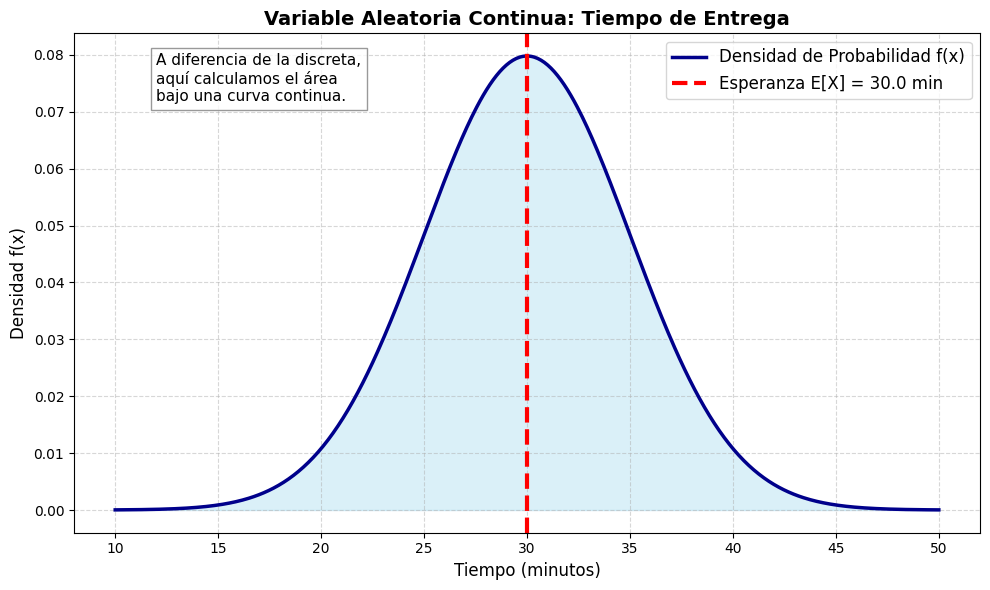

In [2]:
# Ejemplo de Esperanza Matemática: Variable Continua (Tiempo de Entrega)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integrate

# ==========================================
# 1. DEFINICIÓN DE LA VARIABLE CONTINUA
# ==========================================
# X = Tiempo de entrega de un pedido (en minutos)
# Supongamos que sigue una Distribución Normal con media 30 y desviación estándar 5
mu = 30      # Parámetro de ubicación (centro)
sigma = 5    # Parámetro de escala (dispersión)

# Definimos la Función de Densidad de Probabilidad (PDF): f(x)
def f(x):
    return stats.norm.pdf(x, loc=mu, scale=sigma)

# ==========================================
# 2. CÁLCULO DE LA ESPERANZA MATEMÁTICA E[X]
# ==========================================
# Para variables continuas, la Esperanza es la integral de: x * f(x) dx
def funcion_a_integrar(x):
    return x * f(x)

# Calculamos la integral desde -infinito hasta +infinito
esperanza_matematica, error_estimado = integrate.quad(funcion_a_integrar, -np.inf, np.inf)

print("--- CÁLCULO PARA VARIABLE CONTINUA ---")
print(f"Fórmula aplicada: Integral de [x * f(x)] dx")
print(f"La Esperanza Matemática calculada por integración es: {esperanza_matematica:.2f} minutos")
print("--------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
# Generamos un rango de valores para el eje X (de 10 a 50 minutos para ver la campana completa)
x_valores = np.linspace(10, 50, 500)
y_valores = f(x_valores)

plt.figure(figsize=(10, 6))

# Dibujamos la curva de la Función de Densidad de Probabilidad (PDF)
plt.plot(x_valores, y_valores, color='darkblue', linewidth=2.5, label='Densidad de Probabilidad f(x)')

# Sombreamos el área bajo la curva (que representa el 100% de la probabilidad)
plt.fill_between(x_valores, y_valores, alpha=0.3, color='skyblue')

# Agregamos la línea de la Esperanza Matemática (Centro de gravedad)
plt.axvline(x=esperanza_matematica, color='red', linestyle='--', linewidth=3,
            label=f'Esperanza E[X] = {esperanza_matematica:.1f} min')

# Etiquetas y diseño
plt.title('Variable Aleatoria Continua: Tiempo de Entrega', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (minutos)', fontsize=12)
plt.ylabel('Densidad f(x)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# Un pequeño texto explicativo dentro de la gráfica
plt.text(12, max(y_valores)*0.9, "A diferencia de la discreta,\naquí calculamos el área\nbajo una curva continua.",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Mostrar la gráfica
plt.tight_layout()
plt.show()

--- DISTRIBUCIÓN NORMAL ESTÁNDAR Z ~ N(0, 1) ---
Parámetros fijos -> Media (μ): 0, Desviación Estándar (σ): 1
Probabilidad de encontrar un valor entre Z=-1 y Z=1: 68.27%
--------------------------------------------------



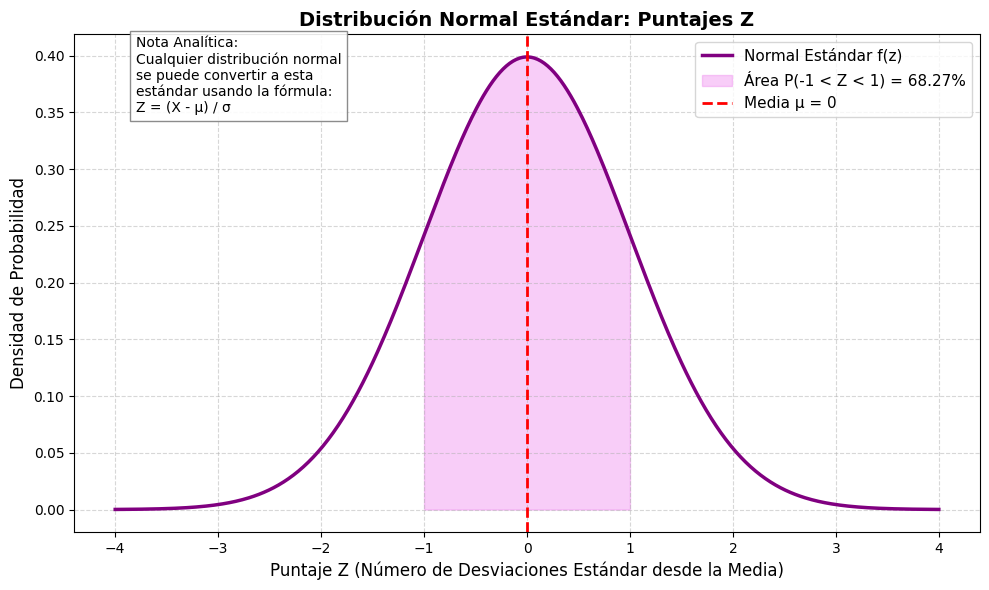

In [3]:
# Ejemplo: Distribución Normal Estándar Z ~ N(0, 1).
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. DEFINICIÓN DE LA NORMAL ESTÁNDAR
# ==========================================
# En la Normal Estándar, los parámetros son fijos por definición:
mu = 0      # La media siempre es el punto de origen (0)
sigma = 1   # La desviación estándar es la unidad (1)

# Generamos un rango de Puntajes Z desde -4 hasta 4
# (Esto cubre el 99.99% del área bajo la campana de Gauss)
z_valores = np.linspace(-4, 4, 500)
# Calculamos la densidad (altura de la curva) para cada Z
pdf_valores = stats.norm.pdf(z_valores, loc=mu, scale=sigma)

# ==========================================
# 2. CÁLCULO DE PROBABILIDAD CON Z-SCORES
# ==========================================
# Vamos a calcular qué porcentaje de los datos cae entre Z = -1 y Z = 1
# (Esto se conoce en estadística como parte de la Regla Empírica 68-95-99.7)
z_izq = -1
z_der = 1

# Usamos la CDF (Función de Distribución Acumulada) para calcular áreas
area_der = stats.norm.cdf(z_der, loc=mu, scale=sigma) # Área desde -infinito hasta 1
area_izq = stats.norm.cdf(z_izq, loc=mu, scale=sigma) # Área desde -infinito hasta -1

# La probabilidad entre ambos puntos es la resta de las áreas acumuladas
probabilidad = area_der - area_izq

print("--- DISTRIBUCIÓN NORMAL ESTÁNDAR Z ~ N(0, 1) ---")
print(f"Parámetros fijos -> Media (μ): {mu}, Desviación Estándar (σ): {sigma}")
print(f"Probabilidad de encontrar un valor entre Z={z_izq} y Z={z_der}: {probabilidad*100:.2f}%")
print("--------------------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Dibujamos la campana de Gauss
plt.plot(z_valores, pdf_valores, color='purple', linewidth=2.5, label='Normal Estándar f(z)')

# Sombreamos el área que calculamos (entre -1 y 1)
z_area = np.linspace(z_izq, z_der, 100)
pdf_area = stats.norm.pdf(z_area, loc=mu, scale=sigma)
plt.fill_between(z_area, pdf_area, color='violet', alpha=0.4,
                 label=f'Área P(-1 < Z < 1) = {probabilidad*100:.2f}%')

# Marcamos el centro (Media)
plt.axvline(x=mu, color='red', linestyle='--', linewidth=2, label='Media μ = 0')

# Etiquetas y diseño estético
plt.title('Distribución Normal Estándar: Puntajes Z', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje Z (Número de Desviaciones Estándar desde la Media)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)

# Forzamos a que el eje X muestre los números enteros exactos para los Z-scores
plt.xticks(np.arange(-4, 5, 1))
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Cuadro de texto explicativo en la gráfica
plt.text(-3.8, 0.35, "Nota Analítica:\nCualquier distribución normal\nse puede convertir a esta\nestándar usando la fórmula:\nZ = (X - μ) / σ",
         fontsize=10, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

--- DISTRIBUCIÓN BINOMIAL X ~ Bin(10, 0.30) ---
Esperanza Matemática E[X] = 10 * 0.3 = 3.0 clientes

Tabla de Probabilidades (resumen):
   Clientes que compran (X)  Probabilidad P(X)
0                         0             0.0282
1                         1             0.1211
2                         2             0.2335
3                         3             0.2668
4                         4             0.2001
5                         5             0.1029
6                         6             0.0368
-----------------------------------------------



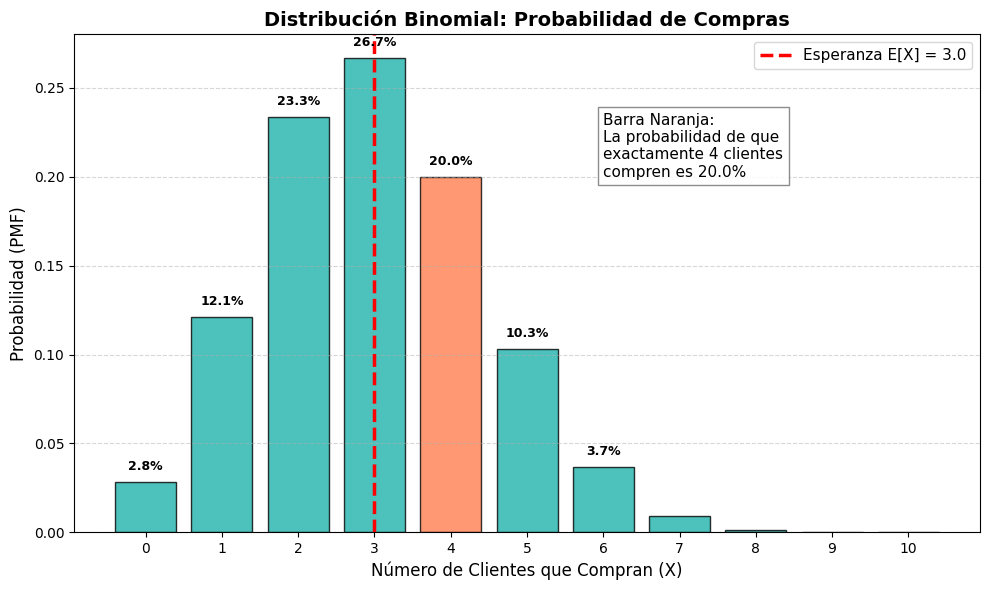

In [4]:
# Ejemplo: Distribución Binomial (Conversión de Clientes).
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. DEFINICIÓN DE PARÁMETROS BINOMIALES
# ==========================================
n = 10      # Número total de ensayos (Ej. 10 clientes visitan la web)
p = 0.30    # Probabilidad de éxito en cada ensayo (Ej. 30% de tasa de conversión)

# Generamos todos los posibles resultados (Desde 0 compras hasta 10 compras)
x_valores = np.arange(0, n + 1)

# ==========================================
# 2. CÁLCULOS DE PROBABILIDAD (PMF)
# ==========================================
# PMF (Probability Mass Function): Calcula la probabilidad exacta para cada valor discreto
probabilidades = stats.binom.pmf(x_valores, n, p)

# Calculamos la Esperanza Matemática teórica: E[X] = n * p
esperanza_matematica = n * p

# Creamos una pequeña tabla para ver los datos (mostramos solo los primeros 6 para no saturar)
df_binomial = pd.DataFrame({
    'Clientes que compran (X)': x_valores,
    'Probabilidad P(X)': np.round(probabilidades, 4)
})

print("--- DISTRIBUCIÓN BINOMIAL X ~ Bin(10, 0.30) ---")
print(f"Esperanza Matemática E[X] = {n} * {p} = {esperanza_matematica} clientes")
print("\nTabla de Probabilidades (resumen):")
print(df_binomial.head(7)) # Mostramos de 0 a 6 compras
print("-----------------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras (usamos barras porque es discreta)
barras = plt.bar(x_valores, probabilidades, color='lightseagreen', edgecolor='black', alpha=0.8)

# Vamos a resaltar un escenario específico para explicarlo (Ej: exactamente 4 compras)
escenario_resaltado = 4
barras[escenario_resaltado].set_color('coral')
barras[escenario_resaltado].set_edgecolor('black')

# Línea de Esperanza Matemática
plt.axvline(x=esperanza_matematica, color='red', linestyle='--', linewidth=2.5,
            label=f'Esperanza E[X] = {esperanza_matematica}')

# Etiquetas y diseño estético
plt.title('Distribución Binomial: Probabilidad de Compras', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clientes que Compran (X)', fontsize=12)
plt.ylabel('Probabilidad (PMF)', fontsize=12)
plt.xticks(x_valores) # Forzamos que se vean todos los números del 0 al 10
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar los porcentajes encima de las barras (solo si son mayores a 1% para que se vea limpio)
for barra in barras:
    yval = barra.get_height()
    if yval > 0.01:
        plt.text(barra.get_x() + barra.get_width()/2, yval + 0.005, f'{yval*100:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Agregamos la leyenda y un texto explicativo
plt.legend(fontsize=11)
plt.text(6, 0.20, f"Barra Naranja:\nLa probabilidad de que\nexactamente {escenario_resaltado} clientes\ncompren es {probabilidades[escenario_resaltado]*100:.1f}%",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

--- DISTRIBUCIÓN EXPONENCIAL X ~ Exp(λ=0.02) ---
Tasa de defectos (λ): 0.02 por kilómetro
Esperanza Matemática E[X]: 50.0 kilómetros de distancia promedio entre defectos
Probabilidad de encontrar un defecto en los primeros 15 km: 25.92%
------------------------------------------------



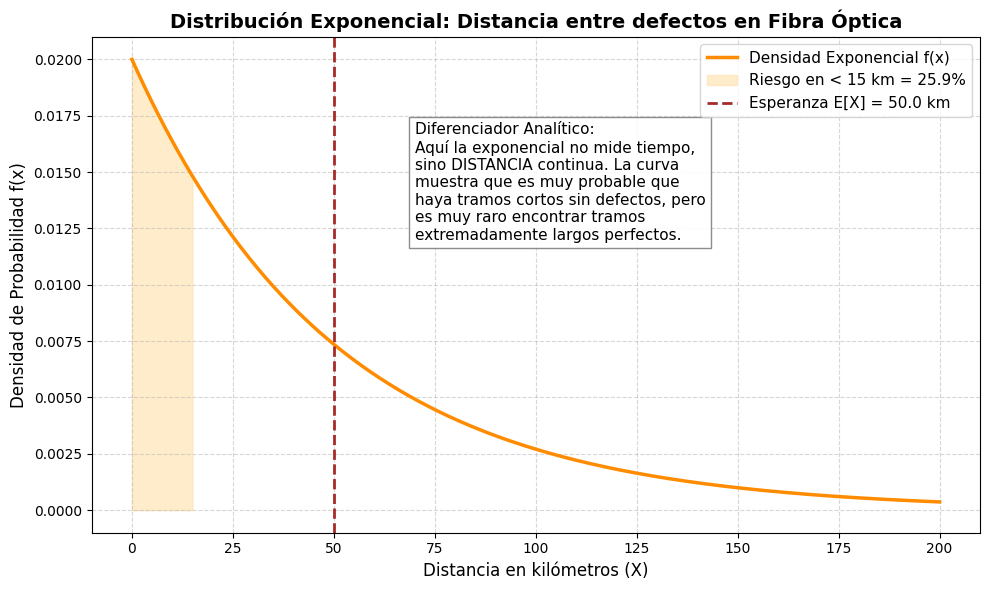

In [5]:
# Ejemplo: Distribución Exponencial (Distancia entre defectos en Fibra Óptica).
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. DEFINICIÓN DEL ESCENARIO ESPACIAL
# ==========================================
# Contexto: Control de calidad en la fabricación de fibra óptica.
# Históricamente, hay 2 defectos microscópicos por cada 100 km de cable.
# Por lo tanto, la tasa (λ) es 0.02 defectos por kilómetro.
tasa_lambda = 0.02

# La Esperanza E[X] (Media) es la inversa de la tasa (1 / λ)
esperanza_matematica = 1 / tasa_lambda  # En kilómetros

# Generamos un rango de distancia en kilómetros (de 0 a 200 km)
x_valores = np.linspace(0, 200, 500)

# ==========================================
# 2. CÁLCULOS DE PROBABILIDAD
# ==========================================
# Generamos la curva de densidad (PDF)
pdf_valores = stats.expon.pdf(x_valores, scale=esperanza_matematica)

# Vamos a calcular una probabilidad de riesgo:
# ¿Qué probabilidad hay de que el cable falle (haya un defecto) en los primeros 15 km?
distancia_critica = 15

# Usamos la CDF (Acumulada) para hallar el área desde 0 hasta 15 km
probabilidad_falla_temprana = stats.expon.cdf(distancia_critica, scale=esperanza_matematica)

print("--- DISTRIBUCIÓN EXPONENCIAL X ~ Exp(λ=0.02) ---")
print(f"Tasa de defectos (λ): {tasa_lambda} por kilómetro")
print(f"Esperanza Matemática E[X]: {esperanza_matematica} kilómetros de distancia promedio entre defectos")
print(f"Probabilidad de encontrar un defecto en los primeros {distancia_critica} km: {probabilidad_falla_temprana*100:.2f}%")
print("------------------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Curva Exponencial
plt.plot(x_valores, pdf_valores, color='darkorange', linewidth=2.5, label='Densidad Exponencial f(x)')

# Sombreamos el área de riesgo (Defecto a menos de 15 km)
x_area = np.linspace(0, distancia_critica, 100)
pdf_area = stats.expon.pdf(x_area, scale=esperanza_matematica)
plt.fill_between(x_area, pdf_area, color='moccasin', alpha=0.7,
                 label=f'Riesgo en < 15 km = {probabilidad_falla_temprana*100:.1f}%')

# Marcamos la Esperanza Matemática
plt.axvline(x=esperanza_matematica, color='brown', linestyle='--', linewidth=2,
            label=f'Esperanza E[X] = {esperanza_matematica} km')

# Etiquetas y diseño estético
plt.title('Distribución Exponencial: Distancia entre defectos en Fibra Óptica', fontsize=14, fontweight='bold')
plt.xlabel('Distancia en kilómetros (X)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Cuadro de texto explicativo
plt.text(70, max(pdf_valores)*0.6,
         "Diferenciador Analítico:\nAquí la exponencial no mide tiempo,\nsino DISTANCIA continua. La curva\nmuestra que es muy probable que\nhaya tramos cortos sin defectos, pero\nes muy raro encontrar tramos\nextremadamente largos perfectos.",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

--- DISTRIBUCIÓN GAMMA X ~ Gamma(α=4, β=15) ---
Número de Fases (α): 4
Tiempo promedio por fase (β): 15 minutos
Esperanza Matemática E[X] (Tiempo total esperado): 60 minutos
Probabilidad de terminar todo el proceso en 45 min o menos: 35.28%
--------------------------------------------------



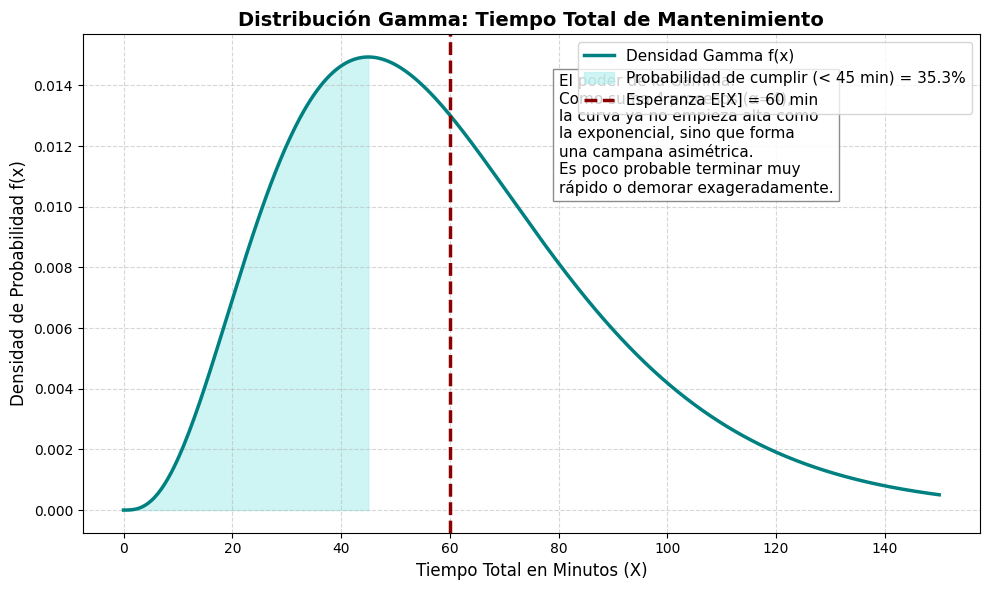

In [6]:
# Ejemplo: Distribución Gamma (Tiempo Total de Mantenimiento en Fases).
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. DEFINICIÓN DE PARÁMETROS GAMMA
# ==========================================
# Contexto: Mantenimiento de un servidor que requiere 4 fases consecutivas.
# Cada fase toma en promedio 15 minutos.

# Parámetro de Forma (Alpha - α): Representa el número de eventos o fases a acumular
alpha = 4

# Parámetro de Escala (Beta - β): Representa el tiempo promedio de CADA evento/fase
beta = 15

# La Esperanza Matemática en la Gamma es simplemente la multiplicación: E[X] = α * β
# (Si son 4 fases de 15 minutos, esperamos tardar 60 minutos en total)
esperanza_matematica = alpha * beta

# Generamos un rango de tiempo en minutos (de 0 a 150 minutos)
x_valores = np.linspace(0, 150, 500)

# ==========================================
# 2. CÁLCULOS DE PROBABILIDAD
# ==========================================
# Generamos la curva de densidad (PDF) usando scipy
# Nota: en scipy, 'a' es el parámetro de forma (alpha) y 'scale' es la escala (beta)
pdf_valores = stats.gamma.pdf(x_valores, a=alpha, scale=beta)

# Escenario de negocio: ¿Qué probabilidad hay de lograr entregar el equipo
# en el tiempo óptimo que promete la empresa (máximo 45 minutos)?
tiempo_promesa = 45

# Usamos la CDF (Acumulada) para hallar el área desde 0 hasta los 45 minutos
prob_cumplir_promesa = stats.gamma.cdf(tiempo_promesa, a=alpha, scale=beta)

print("--- DISTRIBUCIÓN GAMMA X ~ Gamma(α=4, β=15) ---")
print(f"Número de Fases (α): {alpha}")
print(f"Tiempo promedio por fase (β): {beta} minutos")
print(f"Esperanza Matemática E[X] (Tiempo total esperado): {esperanza_matematica} minutos")
print(f"Probabilidad de terminar todo el proceso en 45 min o menos: {prob_cumplir_promesa*100:.2f}%")
print("--------------------------------------------------\n")

# ==========================================
# 3. VISUALIZACIÓN GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Dibujamos la curva de la Función de Densidad Gamma
plt.plot(x_valores, pdf_valores, color='teal', linewidth=2.5, label='Densidad Gamma f(x)')

# Sombreamos el área de cumplimiento (Terminar en <= 45 min)
x_area = np.linspace(0, tiempo_promesa, 100)
pdf_area = stats.gamma.pdf(x_area, a=alpha, scale=beta)
plt.fill_between(x_area, pdf_area, color='paleturquoise', alpha=0.6,
                 label=f'Probabilidad de cumplir (< 45 min) = {prob_cumplir_promesa*100:.1f}%')

# Marcamos la Esperanza Matemática (Centro de gravedad)
plt.axvline(x=esperanza_matematica, color='darkred', linestyle='--', linewidth=2.5,
            label=f'Esperanza E[X] = {esperanza_matematica} min')

# Etiquetas y diseño estético
plt.title('Distribución Gamma: Tiempo Total de Mantenimiento', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo Total en Minutos (X)', fontsize=12)
plt.ylabel('Densidad de Probabilidad f(x)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Cuadro de texto explicativo en la gráfica
plt.text(80, max(pdf_valores)*0.7,
         "El poder de la Gamma:\nComo suma 4 procesos (α=4),\nla curva ya no empieza alta como\nla exponencial, sino que forma\nuna campana asimétrica.\nEs poco probable terminar muy\nrápido o demorar exageradamente.",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()